In [1]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/ATML/PA1")
TASK1_ROOT = PROJECT_ROOT / "task1"

DATA_ROOT = PROJECT_ROOT / "datasets"

SPLITS_DIR = TASK1_ROOT / "splits"
FEATURES_DIR = TASK1_ROOT / "cached_features"
CHECKPOINTS_DIR = TASK1_ROOT / "checkpoints"
RESULTS_DIR = TASK1_ROOT / "results"
FIGURES_DIR = TASK1_ROOT / "figures"

for directory in [
    DATA_ROOT,
    SPLITS_DIR,
    FEATURES_DIR,
    CHECKPOINTS_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Task 1 root:", TASK1_ROOT)

Task 1 root: /content/drive/MyDrive/ATML/PA1/task1


In [4]:
import copy
import json
import random
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision import transforms
from torchvision.datasets import STL10
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    vit_b_16,
    ViT_B_16_Weights,
)

import open_clip

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm.auto import tqdm

In [5]:
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("OpenCLIP:", open_clip.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
OpenCLIP: 3.3.0
CUDA available: True
GPU: Tesla T4


In [6]:
SEED = 6304

IMAGE_SIZE = 224
NUM_CLASSES = 10

FEATURE_BATCH_SIZE = 64
HEAD_BATCH_SIZE = 256

MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck",
]

print("Device:", DEVICE)

Device: cuda


In [7]:
def set_seed(seed=6304):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [8]:
train_dataset_raw = STL10(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=None,
)

test_dataset_raw = STL10(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=None,
)

print("Official training images:", len(train_dataset_raw))
print("Official test images:", len(test_dataset_raw))
print("Classes:", CLASS_NAMES)

100%|██████████| 2.64G/2.64G [01:33<00:00, 28.2MB/s]


Official training images: 5000
Official test images: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [9]:
TRAIN_VAL_SPLIT_PATH = SPLITS_DIR / "stl10_train_val_seed6304.json"

if TRAIN_VAL_SPLIT_PATH.exists():
    with open(TRAIN_VAL_SPLIT_PATH, "r") as file:
        saved_split = json.load(file)

    train_indices = np.array(saved_split["train_indices"])
    val_indices = np.array(saved_split["val_indices"])

    print("Loaded existing training/validation split.")

else:
    all_train_indices = np.arange(len(train_dataset_raw))
    all_train_labels = np.array(train_dataset_raw.labels)

    train_indices, val_indices = train_test_split(
        all_train_indices,
        test_size=0.20,
        random_state=SEED,
        stratify=all_train_labels,
    )

    saved_split = {
        "seed": SEED,
        "train_indices": train_indices.tolist(),
        "val_indices": val_indices.tolist(),
    }

    with open(TRAIN_VAL_SPLIT_PATH, "w") as file:
        json.dump(saved_split, file, indent=2)

    print("Created and saved a new training/validation split.")

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))

Created and saved a new training/validation split.
Training images: 4000
Validation images: 1000


In [10]:
def count_classes(labels, indices):
    selected_labels = np.array(labels)[indices]
    return np.bincount(selected_labels, minlength=NUM_CLASSES)


train_class_counts = count_classes(train_dataset_raw.labels, train_indices)
val_class_counts = count_classes(train_dataset_raw.labels, val_indices)

split_counts = pd.DataFrame({
    "class": CLASS_NAMES,
    "train_count": train_class_counts,
    "validation_count": val_class_counts,
})

split_counts

,class,train_count,validation_count
0,airplane,400,100
1,bird,400,100
2,car,400,100
3,cat,400,100
4,deer,400,100
5,dog,400,100
6,horse,400,100
7,monkey,400,100
8,ship,400,100
9,truck,400,100


In [11]:
TEST_SUBSET_PATH = SPLITS_DIR / "stl10_test_subset_500_seed6304.json"

if TEST_SUBSET_PATH.exists():
    with open(TEST_SUBSET_PATH, "r") as file:
        saved_test_subset = json.load(file)

    test_indices = np.array(saved_test_subset["test_indices"])

    print("Loaded existing test subset.")

else:
    rng = np.random.default_rng(SEED)
    test_labels = np.array(test_dataset_raw.labels)

    selected_indices = []

    for class_id in range(NUM_CLASSES):
        class_indices = np.where(test_labels == class_id)[0]

        chosen_indices = rng.choice(
            class_indices,
            size=50,
            replace=False,
        )

        selected_indices.extend(chosen_indices.tolist())

    test_indices = np.array(selected_indices)

    # Shuffle the complete selected subset while preserving its membership.
    rng.shuffle(test_indices)

    saved_test_subset = {
        "seed": SEED,
        "number_of_images": len(test_indices),
        "images_per_class": 50,
        "test_indices": test_indices.tolist(),
    }

    with open(TEST_SUBSET_PATH, "w") as file:
        json.dump(saved_test_subset, file, indent=2)

    print("Created and saved a new test subset.")

print("Selected test images:", len(test_indices))

Created and saved a new test subset.
Selected test images: 500


In [12]:
test_class_counts = count_classes(
    test_dataset_raw.labels,
    test_indices,
)

test_subset_counts = pd.DataFrame({
    "class": CLASS_NAMES,
    "test_count": test_class_counts,
})

test_subset_counts

,class,test_count
0,airplane,50
1,bird,50
2,car,50
3,cat,50
4,deer,50
5,dog,50
6,horse,50
7,monkey,50
8,ship,50
9,truck,50


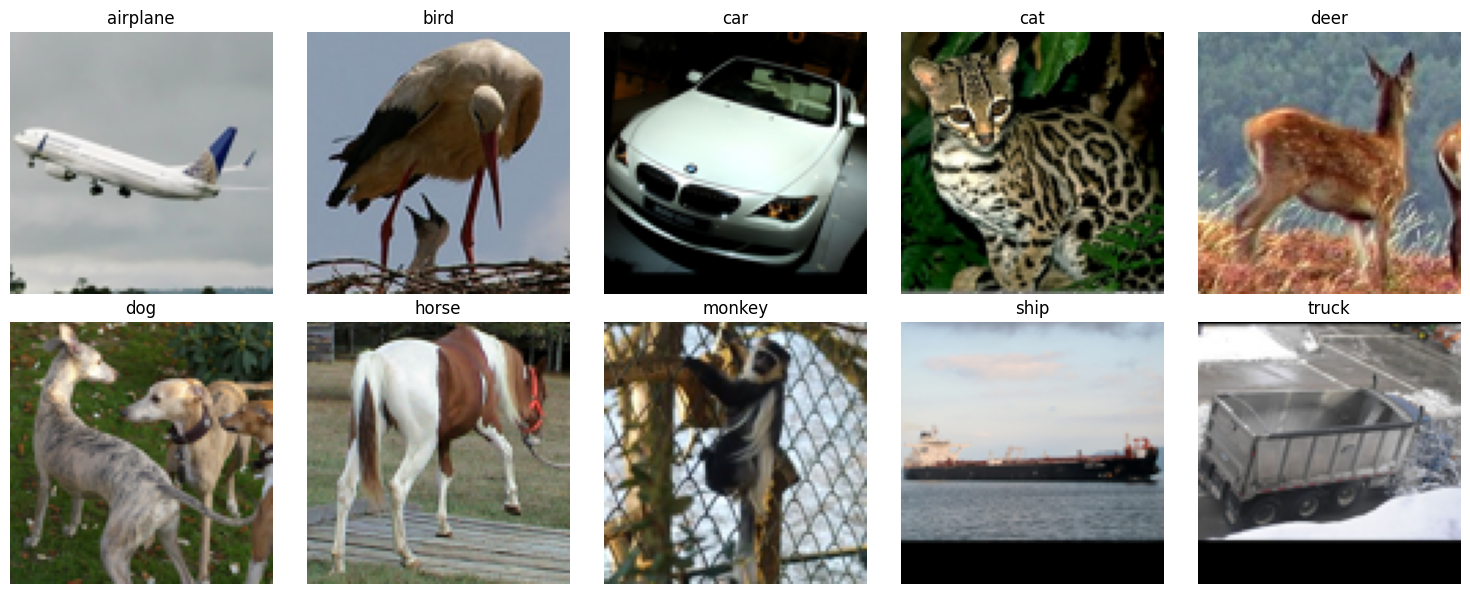

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for class_id, axis in enumerate(axes.flat):
    class_test_indices = [
        index
        for index in test_indices
        if test_dataset_raw.labels[index] == class_id
    ]

    image, label = test_dataset_raw[class_test_indices[0]]

    axis.imshow(image)
    axis.set_title(CLASS_NAMES[label])
    axis.axis("off")

plt.tight_layout()
plt.show()

In [14]:
common_resize = transforms.Resize(
    (IMAGE_SIZE, IMAGE_SIZE),
    interpolation=transforms.InterpolationMode.BICUBIC,
    antialias=True,
)

In [15]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

CLIP_MEAN = (
    0.48145466,
    0.45782750,
    0.40821073,
)

CLIP_STD = (
    0.26862954,
    0.26130258,
    0.27577711,
)


def make_model_transform(model_name):
    if model_name in ["resnet50", "vit_b_16"]:
        mean = IMAGENET_MEAN
        std = IMAGENET_STD

    elif model_name == "clip_vit_b_32":
        mean = CLIP_MEAN
        std = CLIP_STD

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return transforms.Compose([
        common_resize,
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

In [16]:
class IndexedTransformDataset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        original_index = int(self.indices[position])

        image, label = self.base_dataset[original_index]

        image = image.convert("RGB")
        image = self.transform(image)

        return image, int(label), original_index

In [23]:
def make_feature_loader(
    base_dataset,
    indices,
    model_name,
    shuffle=False,
):
    dataset = IndexedTransformDataset(
        base_dataset=base_dataset,
        indices=indices,
        transform=make_model_transform(model_name),
    )

    loader = DataLoader(
        dataset,
        batch_size=FEATURE_BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False,
    )

    return loader

In [24]:
class FrozenBackbone(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.model_name = model_name

        if model_name == "resnet50":
            model = resnet50(
                weights=ResNet50_Weights.IMAGENET1K_V2
            )

            model.fc = nn.Identity()

            self.model = model
            self.feature_dim = 2048

        elif model_name == "vit_b_16":
            model = vit_b_16(
                weights=ViT_B_16_Weights.IMAGENET1K_V1
            )

            model.heads = nn.Identity()

            self.model = model
            self.feature_dim = 768

        elif model_name == "clip_vit_b_32":
            model, _, _ = open_clip.create_model_and_transforms(
                model_name="ViT-B-32-quickgelu",
                pretrained="openai",
            )

            self.model = model
            self.feature_dim = self.model.visual.output_dim

        else:
            raise ValueError(f"Unknown model: {model_name}")

        for parameter in self.model.parameters():
            parameter.requires_grad = False

        self.model.eval()

    def forward(self, images):
        if self.model_name == "clip_vit_b_32":
            features = self.model.encode_image(images)

            # The assignment specifically requires normalized CLIP embeddings.
            features = F.normalize(features, dim=1)

        else:
            features = self.model(images)

        return features

In [19]:
@torch.inference_mode()
def extract_features(backbone, loader, description):
    backbone.eval()

    all_features = []
    all_labels = []
    all_indices = []

    for images, labels, indices in tqdm(loader, desc=description):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        features = backbone(images)

        all_features.append(features.float().cpu())
        all_labels.append(labels.cpu())
        all_indices.append(indices.cpu())

    return {
        "features": torch.cat(all_features, dim=0),
        "labels": torch.cat(all_labels, dim=0),
        "indices": torch.cat(all_indices, dim=0),
    }

In [25]:
MODEL_NAMES = [
    "resnet50",
    "vit_b_16",
    "clip_vit_b_32",
]

for model_name in MODEL_NAMES:
    print(f"\nProcessing {model_name}")

    train_feature_path = FEATURES_DIR / f"{model_name}_clean_train.pt"
    val_feature_path = FEATURES_DIR / f"{model_name}_clean_val.pt"
    test_feature_path = FEATURES_DIR / f"{model_name}_clean_test.pt"

    required_paths = [
        train_feature_path,
        val_feature_path,
        test_feature_path,
    ]

    if all(path.exists() for path in required_paths):
        print("Clean features already exist. Skipping extraction.")
        continue

    backbone = FrozenBackbone(model_name).to(DEVICE)

    print("Feature dimension:", backbone.feature_dim)

    train_loader = make_feature_loader(
        train_dataset_raw,
        train_indices,
        model_name,
    )

    val_loader = make_feature_loader(
        train_dataset_raw,
        val_indices,
        model_name,
    )

    test_loader = make_feature_loader(
        test_dataset_raw,
        test_indices,
        model_name,
    )

    train_data = extract_features(
        backbone,
        train_loader,
        f"{model_name}: training features",
    )

    val_data = extract_features(
        backbone,
        val_loader,
        f"{model_name}: validation features",
    )

    test_data = extract_features(
        backbone,
        test_loader,
        f"{model_name}: test features",
    )

    torch.save(train_data, train_feature_path)
    torch.save(val_data, val_feature_path)
    torch.save(test_data, test_feature_path)

    del backbone
    del train_data, val_data, test_data

    torch.cuda.empty_cache()

    print("Features saved.")


Processing resnet50
Clean features already exist. Skipping extraction.

Processing vit_b_16
Clean features already exist. Skipping extraction.

Processing clip_vit_b_32
Feature dimension: 512


clip_vit_b_32: training features:   0%|          | 0/63 [00:00<?, ?it/s]

clip_vit_b_32: validation features:   0%|          | 0/16 [00:00<?, ?it/s]

clip_vit_b_32: test features:   0%|          | 0/8 [00:00<?, ?it/s]

Features saved.


In [28]:
for model_name in MODEL_NAMES:
    data = torch.load(
        FEATURES_DIR / f"{model_name}_clean_train.pt",
        map_location="cpu",
        weights_only=False,
    )

    print(
        f"{model_name:15s}",
        "features:",
        tuple(data["features"].shape),
        "labels:",
        tuple(data["labels"].shape),
    )

resnet50        features: (4000, 2048) labels: (4000,)
vit_b_16        features: (4000, 768) labels: (4000,)
clip_vit_b_32   features: (4000, 512) labels: (4000,)


In [29]:
@torch.inference_mode()
def evaluate_head(head, features, labels):
    head.eval()

    features = features.to(DEVICE)
    labels = labels.to(DEVICE)

    logits = head(features)
    probabilities = torch.softmax(logits, dim=1)

    predictions = probabilities.argmax(dim=1)
    confidence = probabilities.max(dim=1).values

    accuracy = (
        predictions.eq(labels).float().mean().item()
    )

    return {
        "accuracy": accuracy,
        "mean_confidence": confidence.mean().item(),
        "logits": logits.cpu(),
        "probabilities": probabilities.cpu(),
        "predictions": predictions.cpu(),
        "labels": labels.cpu(),
    }

In [31]:
def train_linear_head(
    model_name,
    train_data,
    val_data,
):
    set_seed(SEED)

    feature_dim = train_data["features"].shape[1]

    head = nn.Linear(
        feature_dim,
        NUM_CLASSES,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        head.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    criterion = nn.CrossEntropyLoss()

    train_dataset = TensorDataset(
        train_data["features"].float(),
        train_data["labels"].long(),
    )

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=HEAD_BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )

    best_val_accuracy = -1.0
    best_state = None
    epochs_without_improvement = 0

    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        head.train()

        running_loss = 0.0
        number_correct = 0
        number_seen = 0

        for features, labels in train_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            logits = head(features)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)

            predictions = logits.argmax(dim=1)
            number_correct += predictions.eq(labels).sum().item()
            number_seen += labels.size(0)

        train_loss = running_loss / number_seen
        train_accuracy = number_correct / number_seen

        val_output = evaluate_head(
            head,
            val_data["features"].float(),
            val_data["labels"].long(),
        )

        val_accuracy = val_output["accuracy"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
        })

        print(
            f"{model_name} | "
            f"Epoch {epoch:02d} | "
            f"Loss {train_loss:.4f} | "
            f"Train Acc {train_accuracy:.4f} | "
            f"Val Acc {val_accuracy:.4f}"
        )

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_state = copy.deepcopy(head.state_dict())
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                "Early stopping: validation accuracy "
                f"did not improve for {EARLY_STOPPING_PATIENCE} epochs."
            )
            break

    head.load_state_dict(best_state)

    return head, pd.DataFrame(history)

In [32]:
def calculate_metrics(output):
    labels = output["labels"].numpy()
    predictions = output["predictions"].numpy()

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
        ),
        "mean_max_confidence": output["mean_confidence"],
    }

In [33]:
clean_results = []
trained_heads = {}

for model_name in MODEL_NAMES:
    print(f"\n{'=' * 70}")
    print("Training linear head for:", model_name)
    print(f"{'=' * 70}")

    train_data = torch.load(
        FEATURES_DIR / f"{model_name}_clean_train.pt",
        map_location="cpu",
        weights_only=False,
    )

    val_data = torch.load(
        FEATURES_DIR / f"{model_name}_clean_val.pt",
        map_location="cpu",
        weights_only=False,
    )

    test_data = torch.load(
        FEATURES_DIR / f"{model_name}_clean_test.pt",
        map_location="cpu",
        weights_only=False,
    )

    head, history = train_linear_head(
        model_name,
        train_data,
        val_data,
    )

    trained_heads[model_name] = head

    checkpoint = {
        "model_name": model_name,
        "feature_dim": train_data["features"].shape[1],
        "number_of_classes": NUM_CLASSES,
        "class_names": CLASS_NAMES,
        "state_dict": head.state_dict(),
        "seed": SEED,
    }

    torch.save(
        checkpoint,
        CHECKPOINTS_DIR / f"{model_name}_linear_head.pt",
    )

    history.to_csv(
        RESULTS_DIR / f"{model_name}_head_training_history.csv",
        index=False,
    )

    test_output = evaluate_head(
        head,
        test_data["features"].float(),
        test_data["labels"].long(),
    )

    metrics = calculate_metrics(test_output)

    clean_results.append({
        "model": model_name,
        "evaluation": "linear_head",
        **metrics,
    })

    print("\nTest metrics:")
    print(metrics)


Training linear head for: resnet50
resnet50 | Epoch 01 | Loss 1.8073 | Train Acc 0.6793 | Val Acc 0.9320
resnet50 | Epoch 02 | Loss 1.0100 | Train Acc 0.9600 | Val Acc 0.9540
resnet50 | Epoch 03 | Loss 0.6065 | Train Acc 0.9732 | Val Acc 0.9610
resnet50 | Epoch 04 | Loss 0.4078 | Train Acc 0.9780 | Val Acc 0.9620
resnet50 | Epoch 05 | Loss 0.3016 | Train Acc 0.9800 | Val Acc 0.9630
resnet50 | Epoch 06 | Loss 0.2384 | Train Acc 0.9830 | Val Acc 0.9660
resnet50 | Epoch 07 | Loss 0.1964 | Train Acc 0.9852 | Val Acc 0.9710
resnet50 | Epoch 08 | Loss 0.1666 | Train Acc 0.9870 | Val Acc 0.9700
resnet50 | Epoch 09 | Loss 0.1443 | Train Acc 0.9875 | Val Acc 0.9690
resnet50 | Epoch 10 | Loss 0.1268 | Train Acc 0.9888 | Val Acc 0.9700
resnet50 | Epoch 11 | Loss 0.1130 | Train Acc 0.9898 | Val Acc 0.9720
resnet50 | Epoch 12 | Loss 0.1014 | Train Acc 0.9910 | Val Acc 0.9700
resnet50 | Epoch 13 | Loss 0.0918 | Train Acc 0.9912 | Val Acc 0.9710
resnet50 | Epoch 14 | Loss 0.0837 | Train Acc 0.9920 |

In [39]:
set_seed(SEED)

clip_model, _, _ = open_clip.create_model_and_transforms(
    model_name="ViT-B-32-quickgelu",
    pretrained="openai",
)

clip_model = clip_model.to(DEVICE)
clip_model.eval()

tokenizer = open_clip.get_tokenizer(
    "ViT-B-32-quickgelu"
)

prompts = [
    f"a photo of a {class_name}."
    for class_name in CLASS_NAMES
]

text_tokens = tokenizer(prompts).to(DEVICE)

with torch.inference_mode():
    text_features = clip_model.encode_text(text_tokens)
    text_features = F.normalize(text_features, dim=1)

print("Text feature shape:", text_features.shape)

Text feature shape: torch.Size([10, 512])


In [40]:
clip_test_data = torch.load(
    FEATURES_DIR / "clip_vit_b_32_clean_test.pt",
    map_location="cpu",
    weights_only=False,
)

image_features = clip_test_data["features"].to(DEVICE)
labels = clip_test_data["labels"].to(DEVICE)

with torch.inference_mode():
    logit_scale = clip_model.logit_scale.exp()

    zero_shot_logits = (
        logit_scale
        * image_features
        @ text_features.T
    )

    zero_shot_probabilities = torch.softmax(
        zero_shot_logits,
        dim=1,
    )

    zero_shot_predictions = zero_shot_probabilities.argmax(dim=1)

    zero_shot_confidence = (
        zero_shot_probabilities.max(dim=1).values
    )

zero_shot_output = {
    "logits": zero_shot_logits.cpu(),
    "probabilities": zero_shot_probabilities.cpu(),
    "predictions": zero_shot_predictions.cpu(),
    "labels": labels.cpu(),
    "mean_confidence": zero_shot_confidence.mean().item(),
}

zero_shot_metrics = calculate_metrics(zero_shot_output)

clean_results.append({
    "model": "clip_vit_b_32",
    "evaluation": "zero_shot",
    **zero_shot_metrics,
})

print(zero_shot_metrics)

{'accuracy': 0.98, 'macro_f1': 0.9798839921143818, 'mean_max_confidence': 0.9547561407089233}


In [41]:
clean_results_df = pd.DataFrame(clean_results)

clean_results_df.to_csv(
    RESULTS_DIR / "clean_baseline_metrics.csv",
    index=False,
)

clean_results_df

,model,evaluation,accuracy,macro_f1,mean_max_confidence
0,resnet50,linear_head,0.976,0.976056,0.897834
1,vit_b_16,linear_head,0.974,0.973895,0.958977
2,clip_vit_b_32,linear_head,0.984,0.984016,0.305023
3,clip_vit_b_32,zero_shot,0.980,0.979884,0.954756


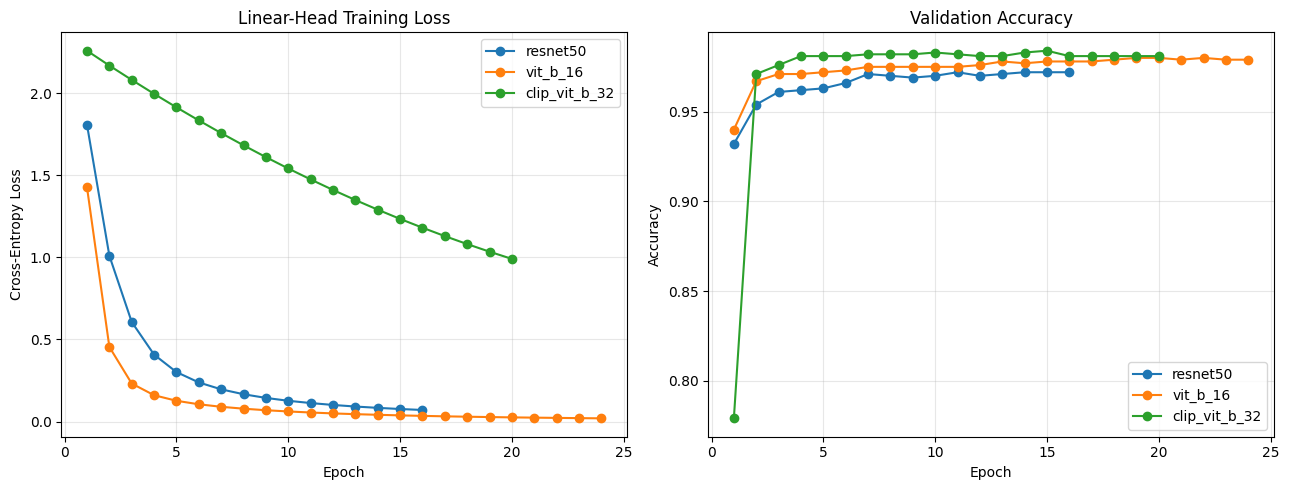

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model_name in MODEL_NAMES:
    history = pd.read_csv(
        RESULTS_DIR / f"{model_name}_head_training_history.csv"
    )

    axes[0].plot(
        history["epoch"],
        history["train_loss"],
        marker="o",
        label=model_name,
    )

    axes[1].plot(
        history["epoch"],
        history["val_accuracy"],
        marker="o",
        label=model_name,
    )

axes[0].set_title("Linear-Head Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "clean_head_training_curves.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()